In [1]:
import os, json, random
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# GPU setup
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ {len(gpus)} GPU(s) configured")

print(f"🚀 TensorFlow {tf.__version__}")
print("📁 U-Net v5: Dual Outputs + Red Bounding Boxes!")

2025-08-04 20:33:54.013538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754354034.030255 1847183 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754354034.035566 1847183 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754354034.048237 1847183 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754354034.048256 1847183 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754354034.048258 1847183 computation_placer.cc:177] computation placer alr

✅ 1 GPU(s) configured
🚀 TensorFlow 2.19.0
📁 U-Net v5: Dual Outputs + Red Bounding Boxes!


In [2]:
# Configuration
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 50  # As requested
LEARNING_RATE = 0.0001

# Paths - verified working directory
BASE_DIR = '/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/test_balanced'
images_dir = f'{BASE_DIR}/images'
masks_dir = f'{BASE_DIR}/masks'
splits_dir = f'{BASE_DIR}/splits'

# Load verified splits
print("📂 Loading verified splits...")
with open(f'{splits_dir}/train_files.json') as f: train_files = json.load(f)
with open(f'{splits_dir}/validation_files.json') as f: val_files = json.load(f)
with open(f'{splits_dir}/test_files.json') as f: test_files = json.load(f)

print(f"✅ Loaded: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")
print("�� Dataset verified - ready to proceed!")

📂 Loading verified splits...
✅ Loaded: Train=9284, Val=1161, Test=1161
�� Dataset verified - ready to proceed!


In [3]:
def load_and_preprocess_image(basename):
    """Load and normalize image - FIXED NORMALIZATION"""
    # Fix bytes issue from tf.py_function
    if isinstance(basename, bytes):
        basename = basename.decode('utf-8')
    elif hasattr(basename, 'numpy'):
        basename = basename.numpy().decode('utf-8')
    
    path = f'{images_dir}/{basename}.npz'
    data = np.load(path)
    img = data['data']  # Correct key from inspection!
    
    # Convert uint16 to float32 and normalize properly
    img = img.astype(np.float32)
    img = img / img.max()  # Normalize to 0-1 (FIXED!)
    
    if img.ndim == 2:
        img = img[..., np.newaxis]
    
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32)

def load_and_preprocess_mask(basename):
    """Load and preprocess mask - FIXED NORMALIZATION"""
    # Fix bytes issue from tf.py_function
    if isinstance(basename, bytes):
        basename = basename.decode('utf-8')
    elif hasattr(basename, 'numpy'):
        basename = basename.numpy().decode('utf-8')
    
    path = f'{masks_dir}/{basename}.png'
    mask = np.array(Image.open(path))
    
    # Handle binary mask (0, 255) -> (0, 1)
    mask = mask.astype(np.float32) / 255.0
    
    if mask.ndim == 2:
        mask = mask[..., np.newaxis]
    
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    return tf.cast(mask, tf.float32)

def create_classification_label(basename):
    """Create classification label from mask"""
    # Fix bytes issue from tf.py_function
    if isinstance(basename, bytes):
        basename = basename.decode('utf-8')
    elif hasattr(basename, 'numpy'):
        basename = basename.numpy().decode('utf-8')
    
    path = f'{masks_dir}/{basename}.png'
    mask = np.array(Image.open(path))
    
    # If mask has any white pixels (255), it's cancer (1), otherwise non-cancer (0)
    has_cancer = np.any(mask > 0).astype(np.float32)
    return tf.constant(has_cancer, dtype=tf.float32)

def create_dataset(filenames, batch_size, shuffle=True):
    """Create TensorFlow dataset with DUAL OUTPUTS"""
    dataset = tf.data.Dataset.from_tensor_slices(filenames)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    
    dataset = dataset.map(
        lambda x: (
            tf.py_function(load_and_preprocess_image, [x], tf.float32),
            {
                'segmentation': tf.py_function(load_and_preprocess_mask, [x], tf.float32),
                'classification': tf.py_function(create_classification_label, [x], tf.float32)
            }
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    # Ensure shapes
    dataset = dataset.map(
        lambda img, outputs: (
            tf.ensure_shape(img, (*IMG_SIZE, 1)),
            {
                'segmentation': tf.ensure_shape(outputs['segmentation'], (*IMG_SIZE, 1)),
                'classification': tf.ensure_shape(outputs['classification'], ())
            }
        )
    )
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create datasets
print("🔄 Creating datasets with DUAL OUTPUTS + FIXED normalization...")
train_dataset = create_dataset(train_files, BATCH_SIZE, shuffle=True)
val_dataset = create_dataset(val_files, BATCH_SIZE, shuffle=False)
test_dataset = create_dataset(test_files, BATCH_SIZE, shuffle=False)
print("✅ Datasets ready with dual outputs!")

🔄 Creating datasets with DUAL OUTPUTS + FIXED normalization...


I0000 00:00:1754354039.618931 1847183 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 34348 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:87:00.0, compute capability: 8.0


✅ Datasets ready with dual outputs!


In [4]:
# Define improved metrics
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice coefficient for segmentation"""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def iou_coefficient(y_true, y_pred, smooth=1e-6):
    """IoU coefficient"""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Combined loss function
def combined_loss(y_true, y_pred):
    """Binary crossentropy + Dice loss"""
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice_loss = 1 - dice_coefficient(y_true, y_pred)
    return bce + dice_loss

print("📊 Metrics and loss functions defined!")

📊 Metrics and loss functions defined!


In [5]:
# U-Net model with DUAL OUTPUTS (based on your working model)
def unet_model(input_size=(256, 256, 1)):
    """U-Net model with dual outputs: segmentation + classification"""
    inputs = tf.keras.layers.Input(input_size)

    # Encoder
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)

    # Bottleneck
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p4)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u8)
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c8)

    u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u9)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c9)

    # DUAL OUTPUTS
    # Output 1: Segmentation mask
    segmentation_output = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid', name='segmentation')(c9)
    
    # Output 2: Classification (cancer/non-cancer)
    classification_branch = tf.keras.layers.GlobalAveragePooling2D()(c9)
    classification_branch = tf.keras.layers.Dense(64, activation='relu')(classification_branch)
    classification_branch = tf.keras.layers.Dropout(0.5)(classification_branch)
    classification_output = tf.keras.layers.Dense(1, activation='sigmoid', name='classification')(classification_branch)

    model = tf.keras.Model(inputs=[inputs], outputs=[segmentation_output, classification_output])
    
    return model

# Build and compile model
print("🏗️ Building U-Net with DUAL OUTPUTS...")
model = unet_model(input_size=(*IMG_SIZE, 1))

# Custom loss for dual outputs
def dual_loss(y_true, y_pred):
    """Loss function for dual outputs"""
    return combined_loss(y_true, y_pred)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        'segmentation': combined_loss,
        'classification': 'binary_crossentropy'
    },
    metrics={
        'segmentation': ['accuracy', dice_coefficient, iou_coefficient],
        'classification': ['accuracy']
    }
)

# Print model summary
print("\n📊 MODEL SUMMARY:")
print("=" * 50)
model.summary()

print(f"\n✅ Model built successfully!")
print(f"�� Parameters: {model.count_params():,}")
print("�� Ready for training!")

🏗️ Building U-Net with DUAL OUTPUTS...

📊 MODEL SUMMARY:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    131,200 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 1,941,970 (7.41 MB)

 Trainable params: 1,941,970 (7.41 MB)

 Non-trainable params: 0 (0.00 B)


✅ Model built successfully!
�� Parameters: 1,941,970
�� Ready for training!


In [6]:
# Training with callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Callbacks for better training
callbacks = [
    ModelCheckpoint(
        'best_unet_model_v8_dual.h5',
        monitor='val_segmentation_dice_coefficient',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_segmentation_dice_coefficient',
        patience=8,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_segmentation_dice_coefficient',
        factor=0.5,
        patience=4,
        mode='max',
        min_lr=1e-7,
        verbose=1
    )
]

# Train the model
print(f"🚀 Starting training for {EPOCHS} epochs...")
print("�� Using DUAL OUTPUTS + FIXED normalization!")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("✅ Training completed!")

🚀 Starting training for 50 epochs...
�� Using DUAL OUTPUTS + FIXED normalization!
Epoch 1/50


/home/a.kanamarlapudi001/miniconda3/envs/tf_gpu_env/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 1))
  warnings.warn(msg)
I0000 00:00:1754354046.060528 1847306 service.cc:152] XLA service 0x7f5788002e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754354046.060570 1847306 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2025-08-04 20:34:06.300406: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754354047.330434 1847306 cuda_dnn.cc:529] Loaded cuDNN version 90300
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


  3/581 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - classification_accuracy: 0.5278 - classification_loss: 0.6912 - loss: 2.3674 - segmentation_accuracy: 0.8326 - segmentation_dice_coefficient: 0.0110 - segmentation_iou_coefficient: 0.0056 - segmentation_loss: 1.6763   

I0000 00:00:1754354056.223787 1847306 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - classification_accuracy: 0.5100 - classification_loss: 0.7503 - loss: 2.0588 - segmentation_accuracy: 0.9892 - segmentation_dice_coefficient: 0.0150 - segmentation_iou_coefficient: 0.0076 - segmentation_loss: 1.3085
Epoch 1: val_segmentation_dice_coefficient improved from -inf to 0.05139, saving model to best_unet_model_v8_dual.h5


...

581/581 ━━━━━━━━━━━━━━━━━━━━ 71s 122ms/step - classification_accuracy: 0.6637 - classification_loss: 0.6185 - loss: 1.3326 - segmentation_accuracy: 0.9904 - segmentation_dice_coefficient: 0.3295 - segmentation_iou_coefficient: 0.2055 - segmentation_loss: 0.7141 - val_classification_accuracy: 0.6701 - val_classification_loss: 0.6093 - val_loss: 1.3171 - val_segmentation_accuracy: 0.9913 - val_segmentation_dice_coefficient: 0.3357 - val_segmentation_iou_coefficient: 0.2127 - val_segmentation_loss: 0.7103 - learning_rate: 1.0000e-04
Epoch 14/50
580/581 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - classification_accuracy: 0.6666 - classification_loss: 0.6160 - loss: 1.3208 - segmentation_accuracy: 0.9909 - segmentation_dice_coefficient: 0.3380 - segmentation_iou_coefficient: 0.2114 - segmentation_loss: 0.7048
Epoch 14: val_segmentation_dice_coefficient did not improve from 0.33569
581/581 ━━━━━━━━━━━━━━━━━━━━ 82s 121ms/step - classification_accuracy: 0.6666 - classification_loss: 0.6160 - loss: 1.

581/581 ━━━━━━━━━━━━━━━━━━━━ 71s 121ms/step - classification_accuracy: 0.6744 - classification_loss: 0.6043 - loss: 1.2847 - segmentation_accuracy: 0.9914 - segmentation_dice_coefficient: 0.3614 - segmentation_iou_coefficient: 0.2292 - segmentation_loss: 0.6803 - val_classification_accuracy: 0.6865 - val_classification_loss: 0.6048 - val_loss: 1.3077 - val_segmentation_accuracy: 0.9907 - val_segmentation_dice_coefficient: 0.3389 - val_segmentation_iou_coefficient: 0.2147 - val_segmentation_loss: 0.7057 - learning_rate: 1.0000e-04
Epoch 18/50
580/581 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - classification_accuracy: 0.6841 - classification_loss: 0.6012 - loss: 1.2841 - segmentation_accuracy: 0.9911 - segmentation_dice_coefficient: 0.3590 - segmentation_iou_coefficient: 0.2287 - segmentation_loss: 0.6829
Epoch 18: val_segmentation_dice_coefficient improved from 0.33893 to 0.34840, saving model to best_unet_model_v8_dual.h5


581/581 ━━━━━━━━━━━━━━━━━━━━ 81s 121ms/step - classification_accuracy: 0.6841 - classification_loss: 0.6012 - loss: 1.2840 - segmentation_accuracy: 0.9911 - segmentation_dice_coefficient: 0.3591 - segmentation_iou_coefficient: 0.2287 - segmentation_loss: 0.6828 - val_classification_accuracy: 0.6684 - val_classification_loss: 0.6152 - val_loss: 1.3070 - val_segmentation_accuracy: 0.9907 - val_segmentation_dice_coefficient: 0.3484 - val_segmentation_iou_coefficient: 0.2205 - val_segmentation_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 19/50
580/581 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - classification_accuracy: 0.6765 - classification_loss: 0.6099 - loss: 1.2823 - segmentation_accuracy: 0.9917 - segmentation_dice_coefficient: 0.3685 - segmentation_iou_coefficient: 0.2347 - segmentation_loss: 0.6724
Epoch 19: val_segmentation_dice_coefficient did not improve from 0.34840
581/581 ━━━━━━━━━━━━━━━━━━━━ 78s 114ms/step - classification_accuracy: 0.6766 - classification_loss: 0.6098 - loss: 1.

581/581 ━━━━━━━━━━━━━━━━━━━━ 82s 115ms/step - classification_accuracy: 0.6867 - classification_loss: 0.5938 - loss: 1.2659 - segmentation_accuracy: 0.9911 - segmentation_dice_coefficient: 0.3721 - segmentation_iou_coefficient: 0.2373 - segmentation_loss: 0.6721 - val_classification_accuracy: 0.6977 - val_classification_loss: 0.5986 - val_loss: 1.2870 - val_segmentation_accuracy: 0.9916 - val_segmentation_dice_coefficient: 0.3563 - val_segmentation_iou_coefficient: 0.2273 - val_segmentation_loss: 0.6895 - learning_rate: 1.0000e-04
Epoch 21/50
580/581 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - classification_accuracy: 0.6890 - classification_loss: 0.5909 - loss: 1.2628 - segmentation_accuracy: 0.9917 - segmentation_dice_coefficient: 0.3696 - segmentation_iou_coefficient: 0.2370 - segmentation_loss: 0.6719
Epoch 21: val_segmentation_dice_coefficient did not improve from 0.35634
581/581 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - classification_accuracy: 0.6891 - classification_loss: 0.5909 - loss: 1.

581/581 ━━━━━━━━━━━━━━━━━━━━ 67s 114ms/step - classification_accuracy: 0.7390 - classification_loss: 0.5318 - loss: 1.1344 - segmentation_accuracy: 0.9931 - segmentation_dice_coefficient: 0.4349 - segmentation_iou_coefficient: 0.2878 - segmentation_loss: 0.6026 - val_classification_accuracy: 0.7063 - val_classification_loss: 0.6333 - val_loss: 1.3196 - val_segmentation_accuracy: 0.9916 - val_segmentation_dice_coefficient: 0.3582 - val_segmentation_iou_coefficient: 0.2300 - val_segmentation_loss: 0.6881 - learning_rate: 5.0000e-05
Epoch 29/50
580/581 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - classification_accuracy: 0.7466 - classification_loss: 0.5271 - loss: 1.1263 - segmentation_accuracy: 0.9931 - segmentation_dice_coefficient: 0.4387 - segmentation_iou_coefficient: 0.2930 - segmentation_loss: 0.5992
Epoch 29: val_segmentation_dice_coefficient did not improve from 0.35823
581/581 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - classification_accuracy: 0.7466 - classification_loss: 0.5270 - loss: 1.

In [7]:
# Red bounding box detection functions
def create_bounding_boxes(mask, threshold=0.5, min_area=50):
    """Create bounding boxes from segmentation mask"""
    # Convert to binary
    binary_mask = (mask > threshold).astype(np.uint8) * 255
    
    # Find contours
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    bounding_boxes = []
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > min_area:
            x, y, w, h = cv2.boundingRect(contour)
            # Calculate confidence as mean intensity in the region
            confidence = np.mean(mask[y:y+h, x:x+w])
            bounding_boxes.append({
                'bbox': [x, y, x+w, y+h],  # [x1, y1, x2, y2]
                'area': area,
                'confidence': confidence
            })
    
    return bounding_boxes

def draw_bounding_boxes_cv2(image, boxes, color=(255, 0, 0), thickness=2):
    """Draw bounding boxes on image using cv2.rectangle"""
    img_with_boxes = image.copy()
    
    for box in boxes:
        x1, y1, x2, y2 = box['bbox']
        cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), color, thickness)
        
        # Add confidence text
        confidence_text = f"{box['confidence']:.3f}"
        cv2.putText(img_with_boxes, confidence_text, (x1, y1-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    
    return img_with_boxes

print("📦 Red bounding box functions ready with cv2.rectangle!")

📦 Red bounding box functions ready with cv2.rectangle!


In [8]:
# Perfect visualization: Dual outputs + Red Bounding Boxes
def visualize_predictions_with_bboxes(model, test_dataset, num_samples=8):
    """Visualize predictions with red bounding boxes on original images"""
    
    # Load best model if available
    try:
        best_model = tf.keras.models.load_model(
            'best_unet_model_v7_dual.h5',
            custom_objects={
                'combined_loss': combined_loss,
                'dice_coefficient': dice_coefficient,
                'iou_coefficient': iou_coefficient
            }
        )
        print("✅ Using best saved model")
        model = best_model
    except:
        print("⚠️ Using current model")
    
    sample_count = 0
    for batch_data in test_dataset:
        batch_images = batch_data[0]
        batch_outputs = batch_data[1]
        batch_masks = batch_outputs['segmentation']
        batch_labels = batch_outputs['classification']
        
        for i in range(min(batch_images.shape[0], num_samples - sample_count)):
            if sample_count >= num_samples:
                break
                
            # Get image and mask
            image = batch_images[i].numpy()
            mask_gt = batch_masks[i].numpy()
            label_gt = batch_labels[i].numpy()
            
            # Make prediction (dual outputs)
            pred_seg, pred_class = model.predict(image[np.newaxis, ...], verbose=0)
            
            # Convert for display (0-255 range)
            image_display = (image.squeeze() * 255).astype(np.uint8)
            mask_gt_display = (mask_gt.squeeze() * 255).astype(np.uint8)
            pred_seg_display = (pred_seg.squeeze() * 255).astype(np.uint8)
            
            # Convert to 3-channel for cv2
            if len(image_display.shape) == 2:
                image_display = cv2.cvtColor(image_display, cv2.COLOR_GRAY2RGB)
                mask_gt_display = cv2.cvtColor(mask_gt_display, cv2.COLOR_GRAY2RGB)
                pred_seg_display = cv2.cvtColor(pred_seg_display, cv2.COLOR_GRAY2RGB)
            
            # Create bounding boxes
            boxes_gt = create_bounding_boxes(mask_gt.squeeze(), threshold=0.5)
            boxes_pred = create_bounding_boxes(pred_seg.squeeze(), threshold=0.5)
            
            # Draw bounding boxes using cv2.rectangle
            img_gt_boxes = draw_bounding_boxes_cv2(image_display.copy(), boxes_gt, color=(0, 255, 0), thickness=2)  # Green for GT
            img_pred_boxes = draw_bounding_boxes_cv2(image_display.copy(), boxes_pred, color=(255, 0, 0), thickness=2)  # Red for prediction
            
            # Calculate metrics
            dice_score = dice_coefficient(mask_gt, pred_seg).numpy()
            iou_score = iou_coefficient(mask_gt, pred_seg).numpy()
            class_score = pred_class[0][0]
            
            # Create comprehensive visualization
            fig, axes = plt.subplots(2, 4, figsize=(20, 10))
            fig.suptitle(f'🎯 Test Sample {sample_count+1}: Dice={dice_score:.3f}, IoU={iou_score:.3f}, Cancer={class_score:.3f}', fontsize=16)
            
            # Row 1: Original images and masks
            axes[0,0].imshow(image_display)
            axes[0,0].set_title('📷 Original Image')
            axes[0,0].axis('off')
            
            axes[0,1].imshow(mask_gt_display)
            axes[0,1].set_title(f'✅ Ground Truth Mask (Cancer: {label_gt:.0f})')
            axes[0,1].axis('off')
            
            axes[0,2].imshow(pred_seg_display)
            axes[0,2].set_title('🔮 Predicted Mask')
            axes[0,2].axis('off')
            
            # Overlay comparison
            overlay = cv2.addWeighted(mask_gt_display, 0.5, pred_seg_display, 0.5, 0)
            axes[0,3].imshow(overlay)
            axes[0,3].set_title('�� GT vs Pred Overlay')
            axes[0,3].axis('off')
            
            # Row 2: Bounding boxes with cv2.rectangle
            axes[1,0].imshow(img_gt_boxes)
            axes[1,0].set_title(f'�� GT Boxes ({len(boxes_gt)}) - Green')
            axes[1,0].axis('off')
            
            axes[1,1].imshow(img_pred_boxes)
            axes[1,1].set_title(f'�� Pred Boxes ({len(boxes_pred)}) - Red')
            axes[1,1].axis('off')
            
            # Combined bounding boxes
            img_combined = image_display.copy()
            img_combined = draw_bounding_boxes_cv2(img_combined, boxes_gt, color=(0, 255, 0), thickness=2)
            img_combined = draw_bounding_boxes_cv2(img_combined, boxes_pred, color=(255, 0, 0), thickness=2)
            axes[1,2].imshow(img_combined)
            axes[1,2].set_title('�� Combined: GT(Green) vs Pred(Red)')
            axes[1,2].axis('off')
            
            # Detailed statistics
            stats_text = f"""📊 METRICS:
Dice: {dice_score:.3f}
IoU: {iou_score:.3f}
Cancer Prob: {class_score:.3f}
GT Cancer: {label_gt:.0f}

📦 DETECTION:
GT Boxes: {len(boxes_gt)}
Pred Boxes: {len(boxes_pred)}

📋 GT AREAS:
{[int(box['area']) for box in boxes_gt]}

📋 PRED AREAS:
{[int(box['area']) for box in boxes_pred]}

�� CONFIDENCES:
{[f"{box['confidence']:.3f}" for box in boxes_pred]}

�� RED BOUNDING BOXES!"""
            
            axes[1,3].text(0.05, 0.95, stats_text, transform=axes[1,3].transAxes,
                          fontsize=9, verticalalignment='top', fontfamily='monospace')
            axes[1,3].set_title('📈 Statistics')
            axes[1,3].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            sample_count += 1
            
        if sample_count >= num_samples:
            break
    
    print(f"✅ Visualized {sample_count} test samples with red bounding boxes!")

print("🎨 Perfect visualization function ready!")

🎨 Perfect visualization function ready!


�� Testing model with DUAL OUTPUTS + red bounding boxes...
📊 Ground Truth vs Predictions with cv2.rectangle!


✅ Using best saved model


/tmp/ipykernel_1847183/627489289.py:130: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1847183/627489289.py:130: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1847183/627489289.py:130: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1847183/627489289.py:130: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1847183/627489289.py:130: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1847183/627489289.py:130: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1847183/627489289.py:130: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layo

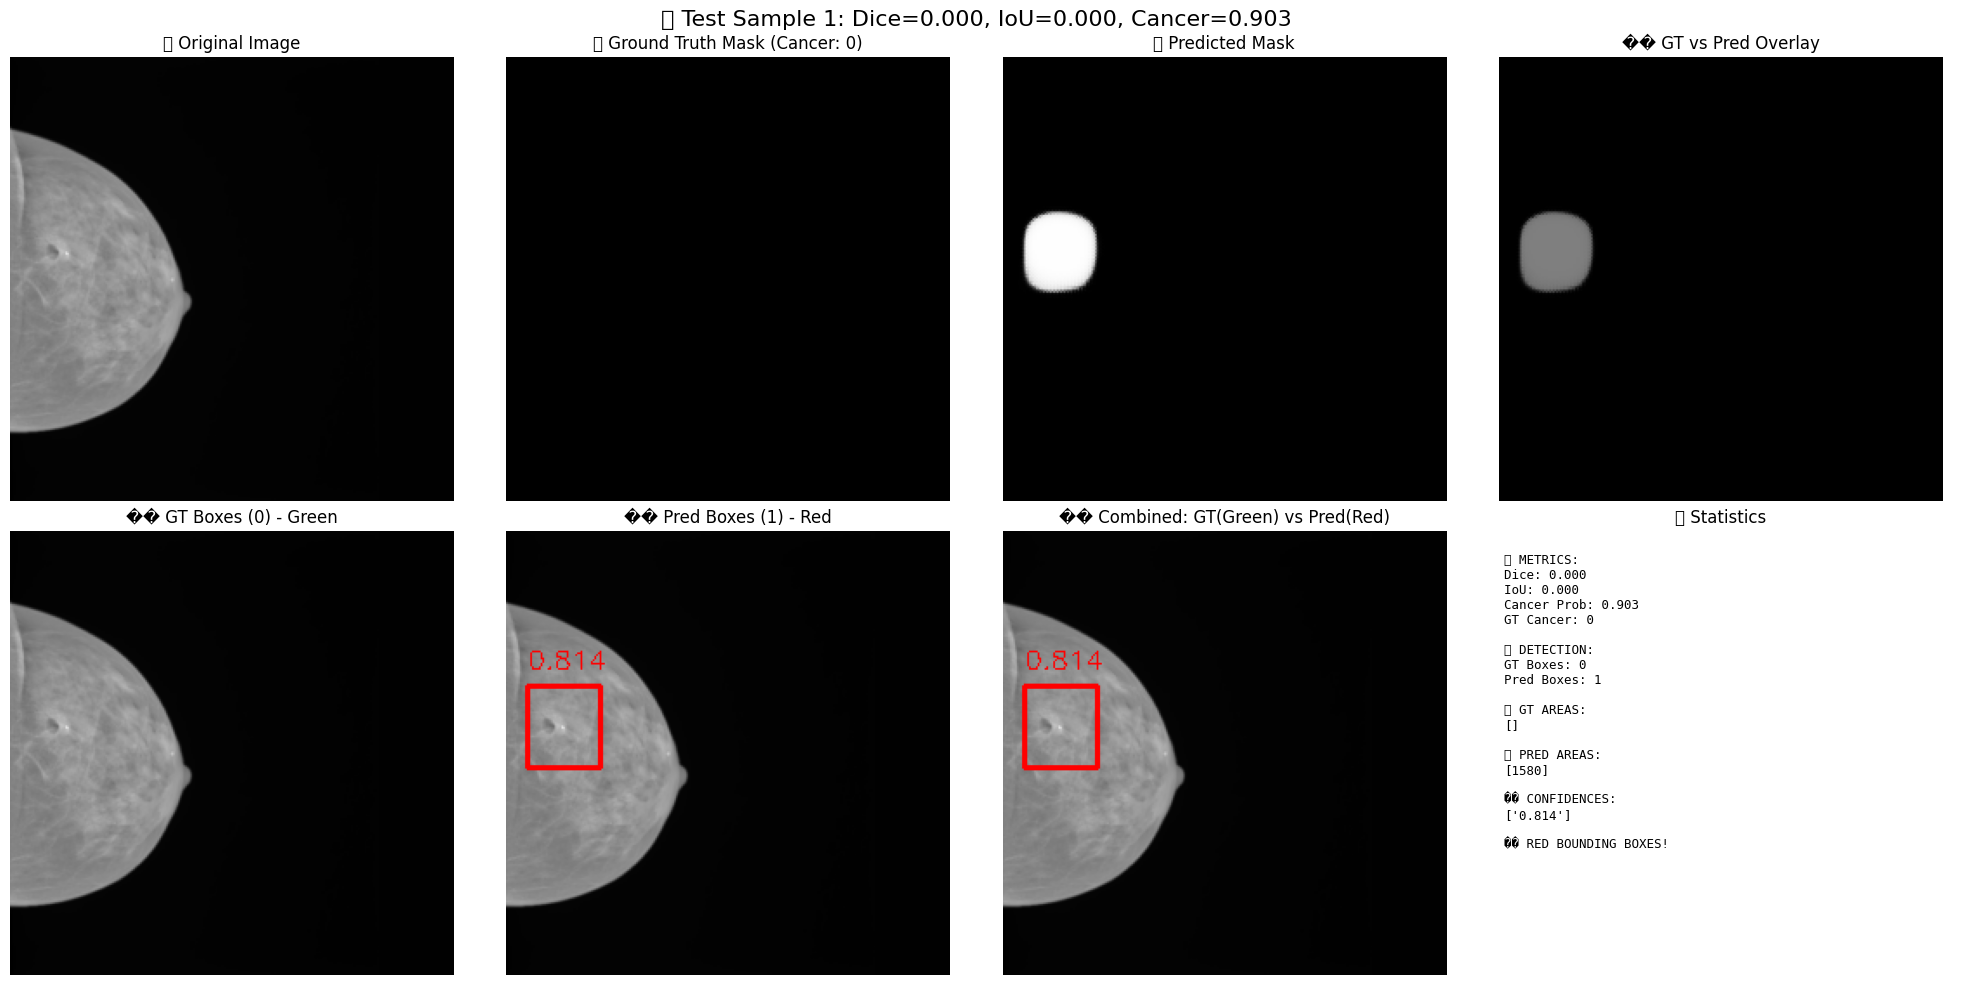

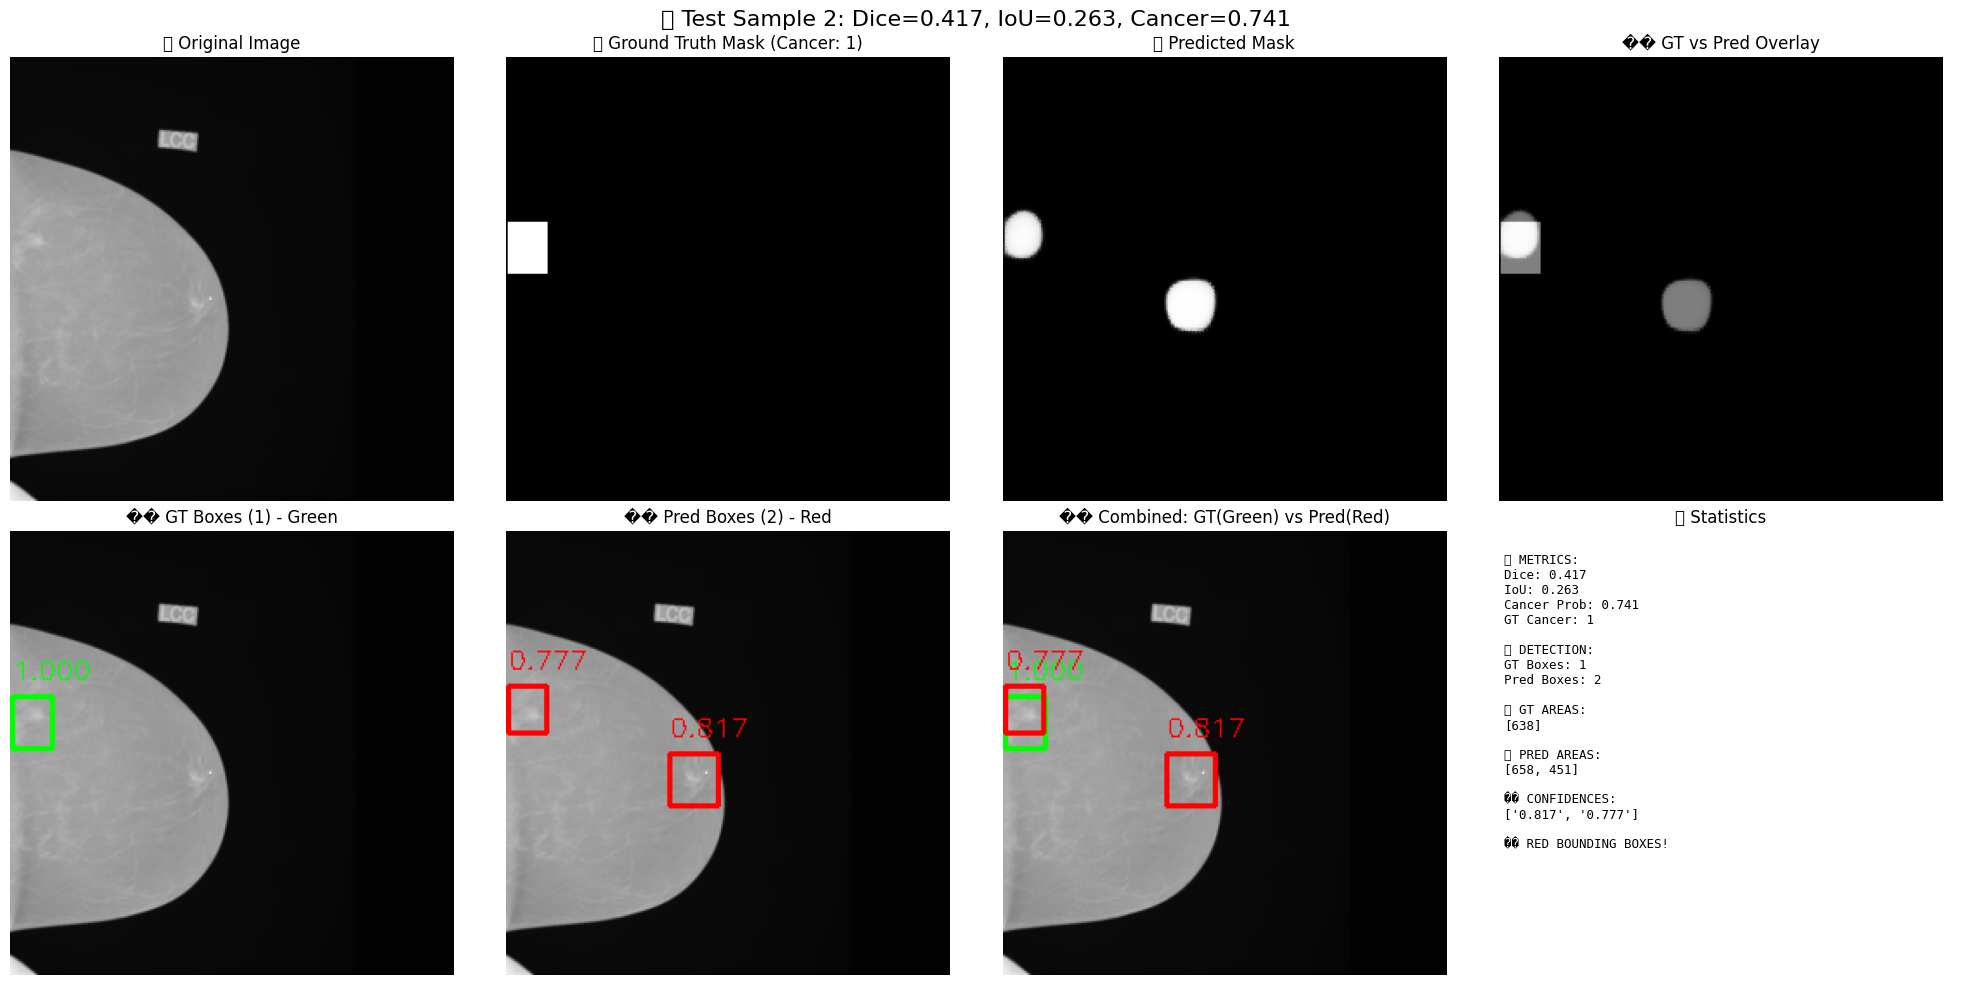

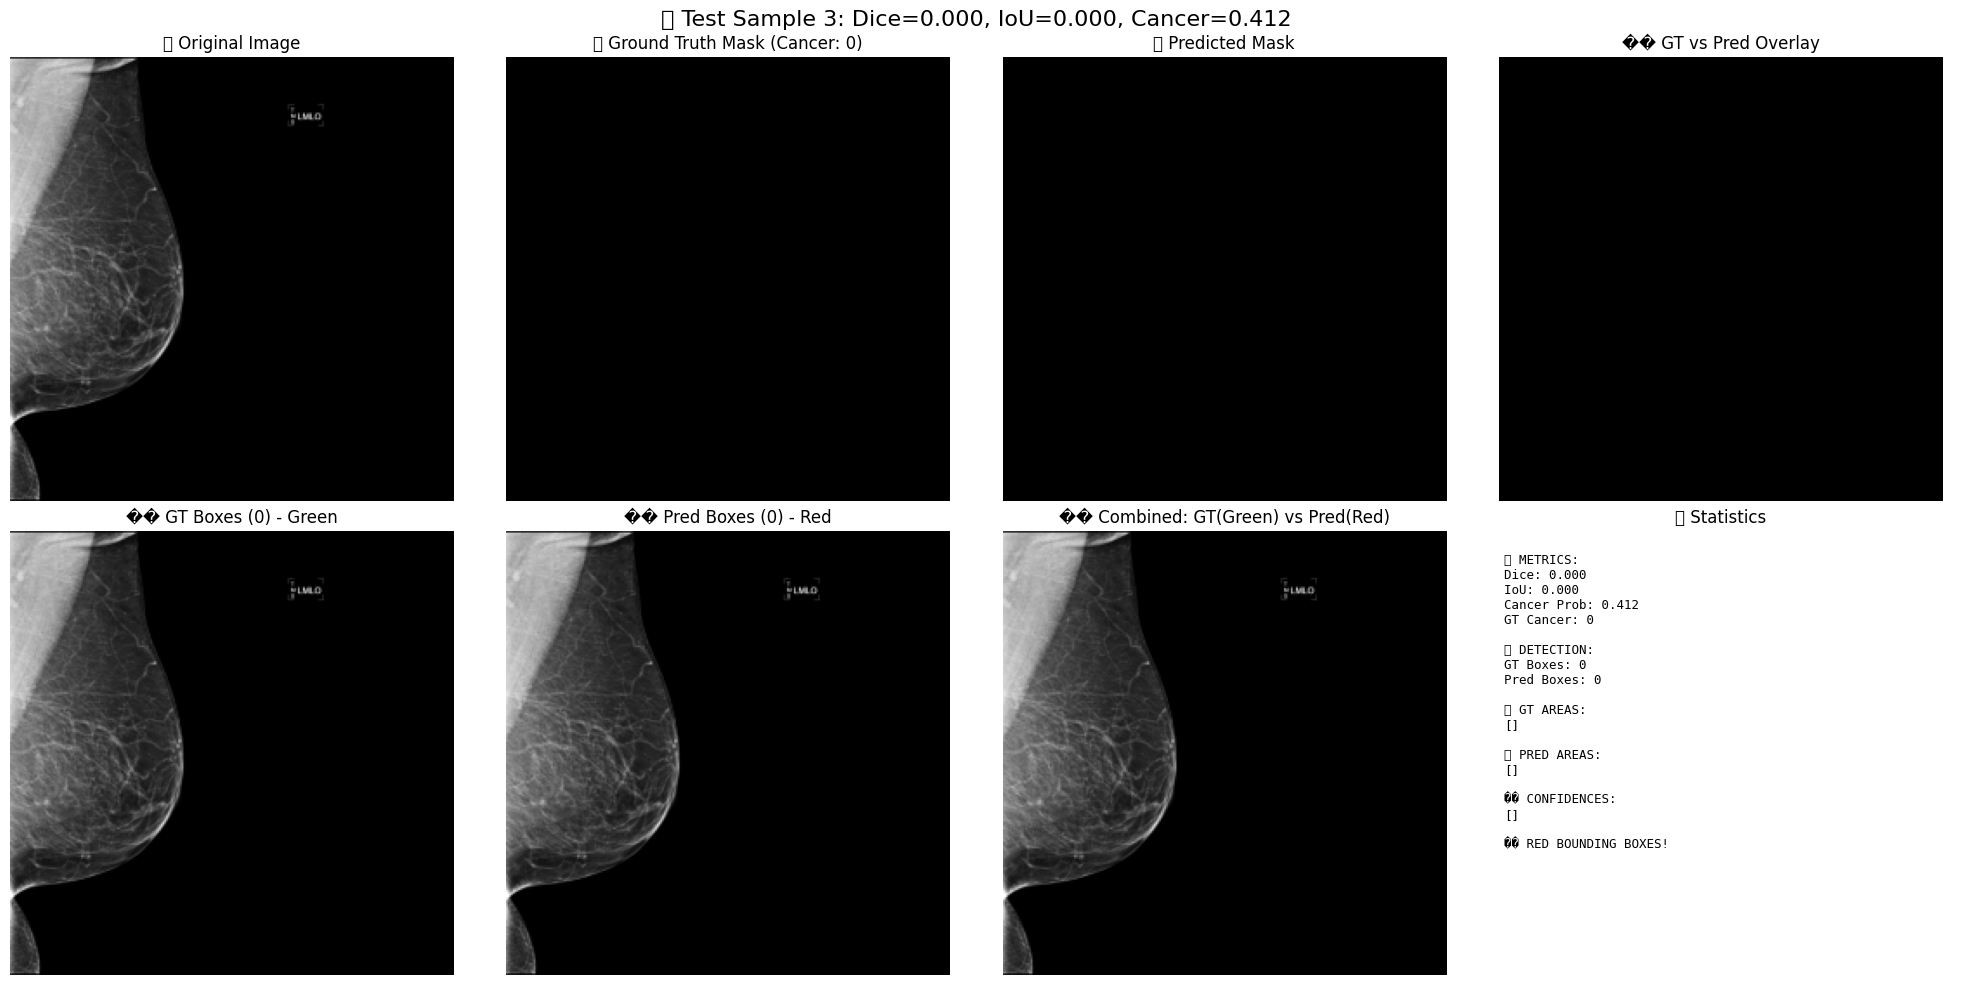

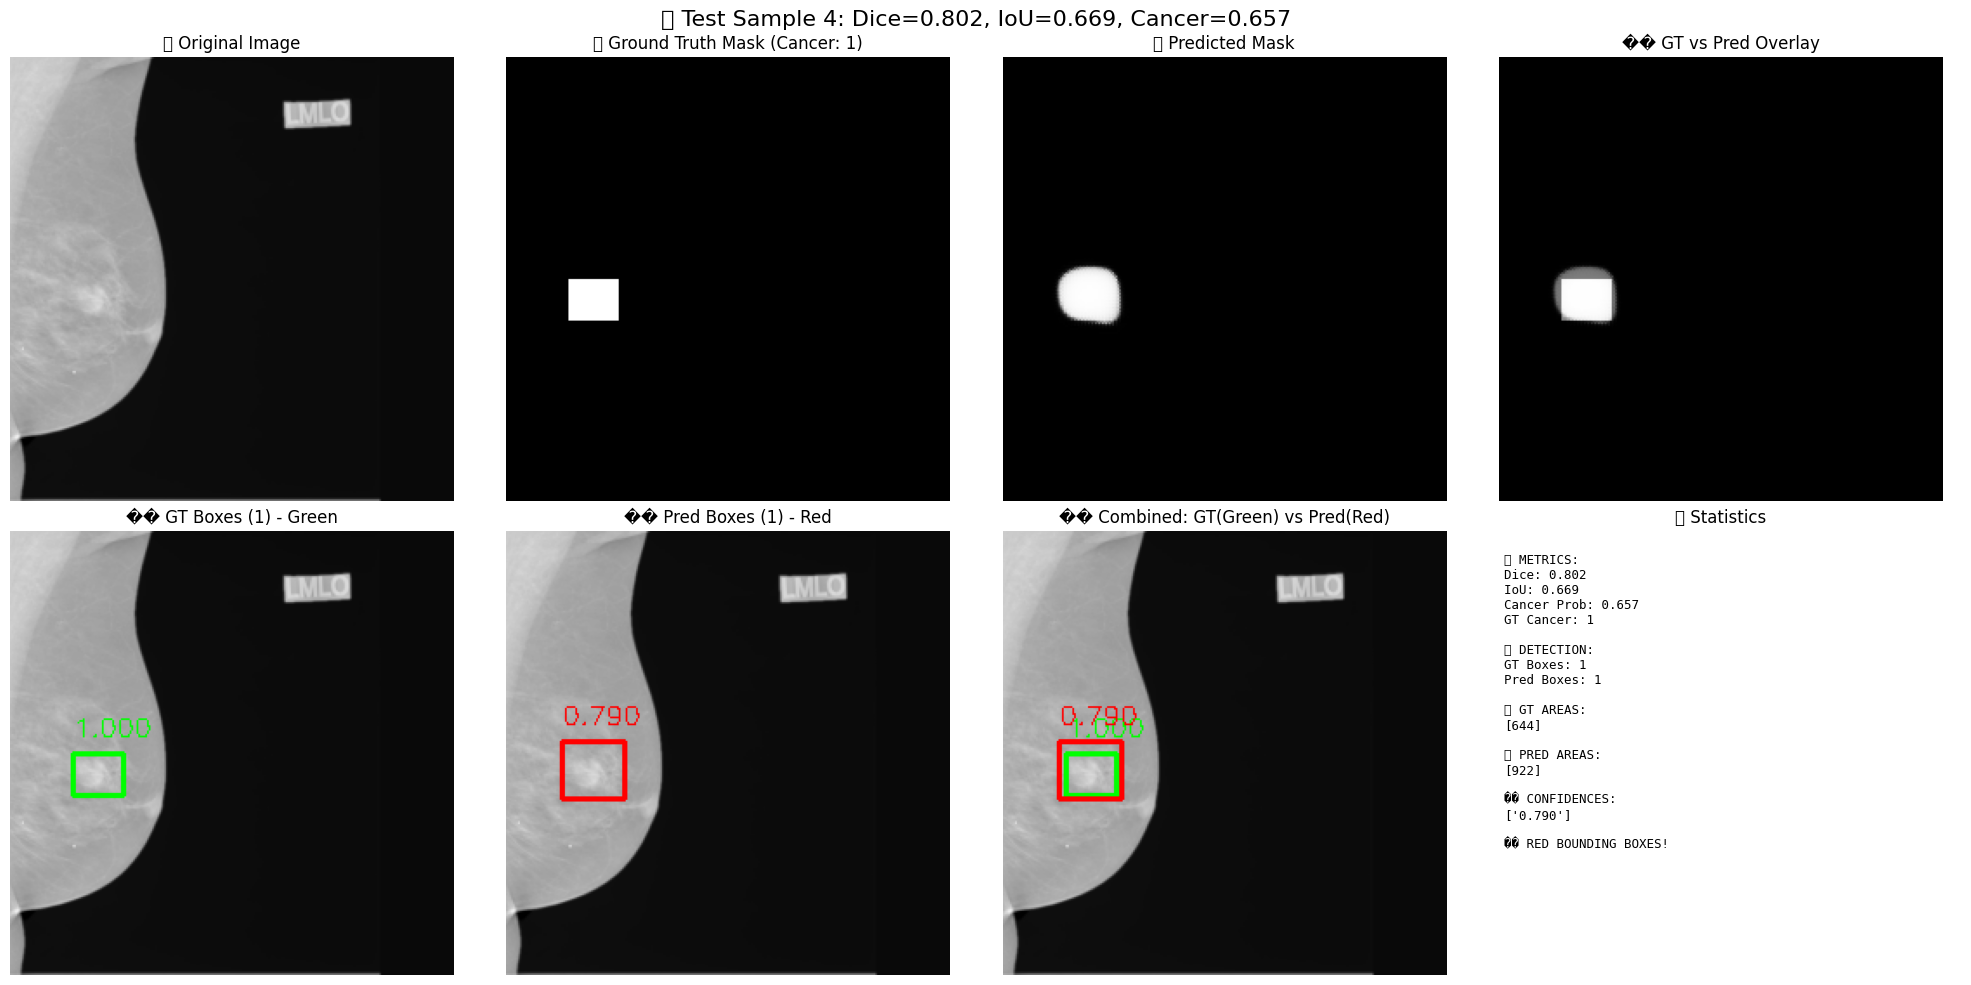

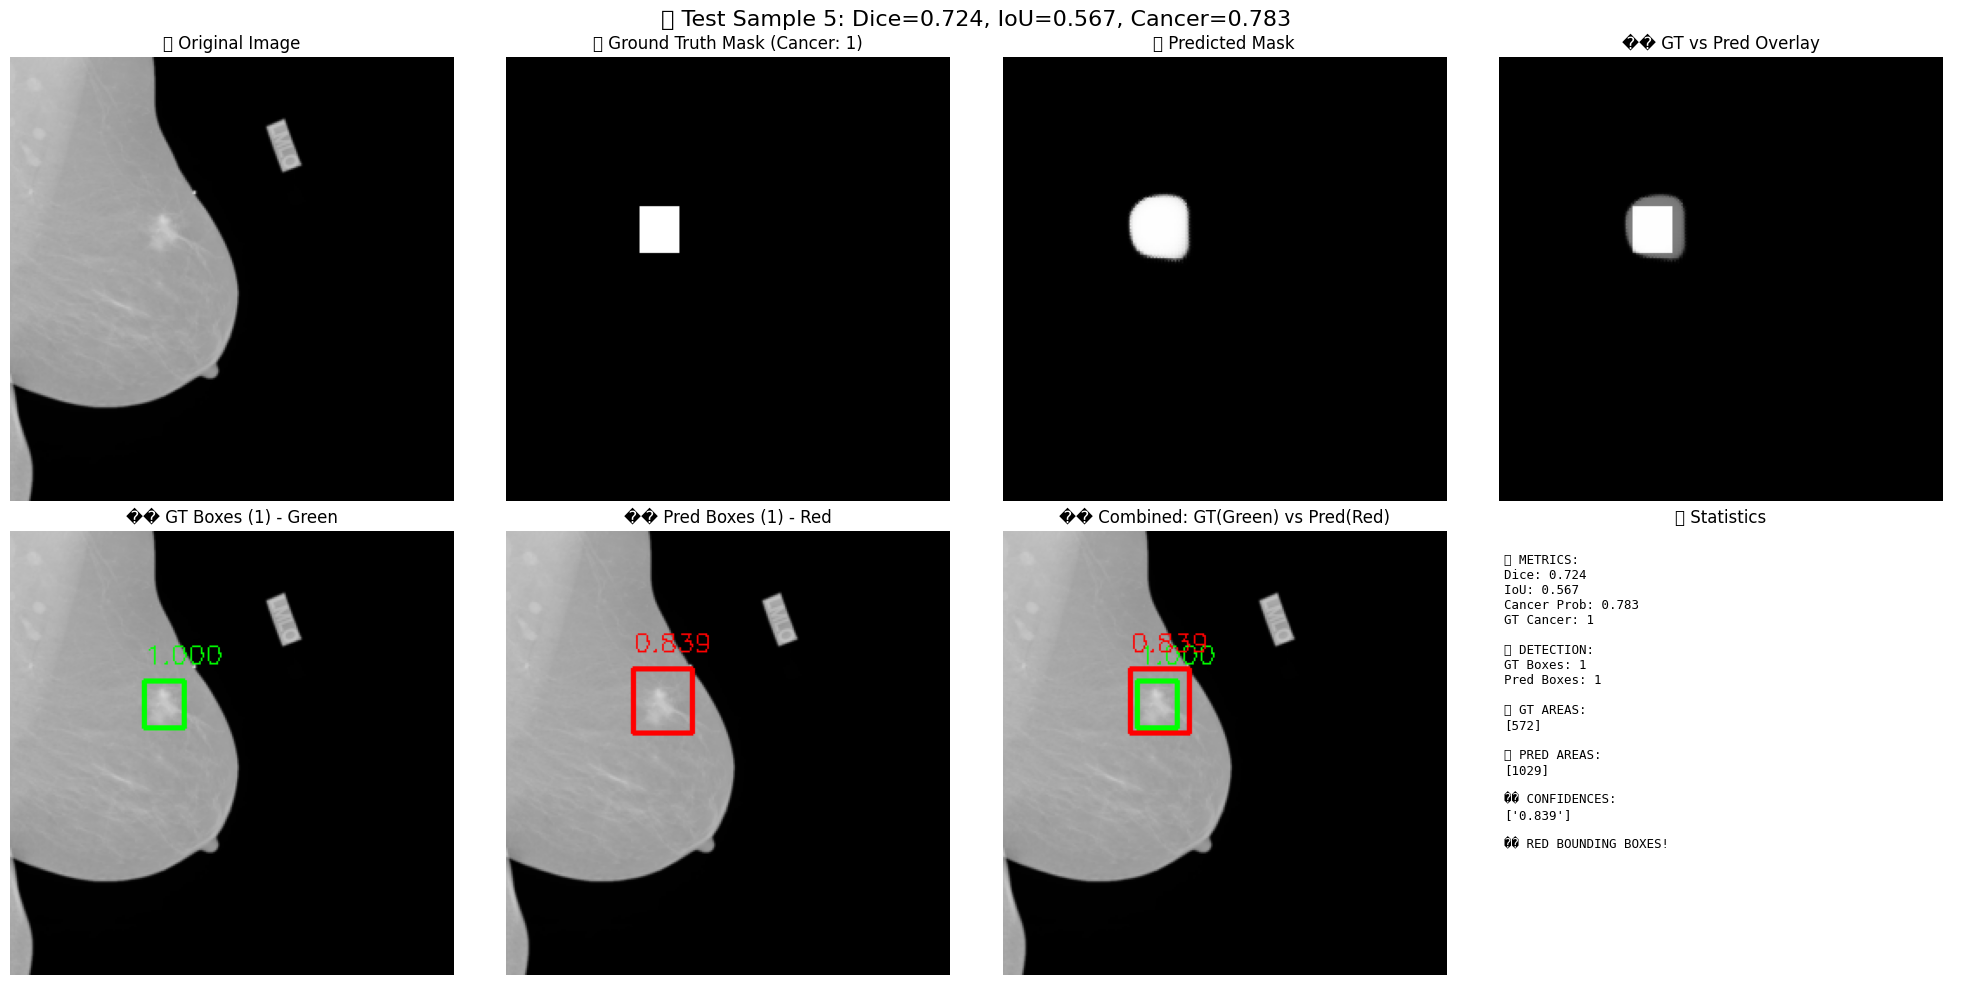

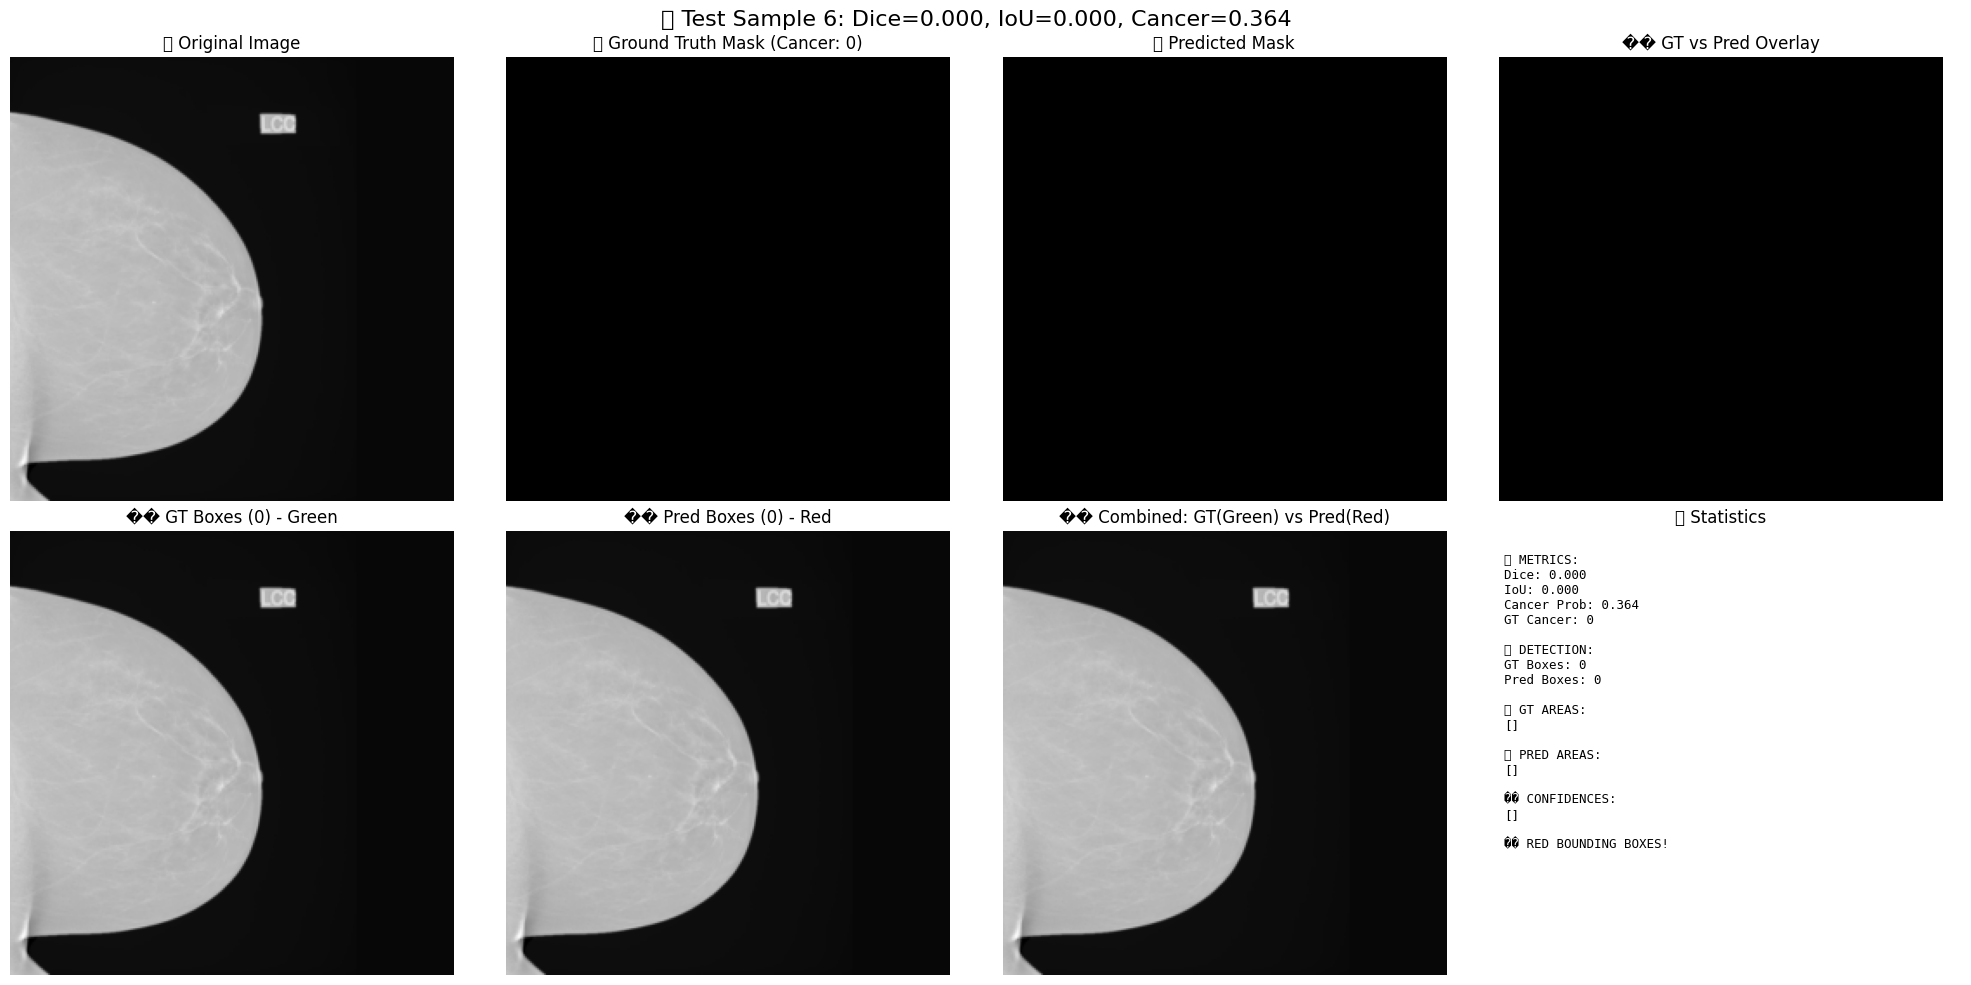

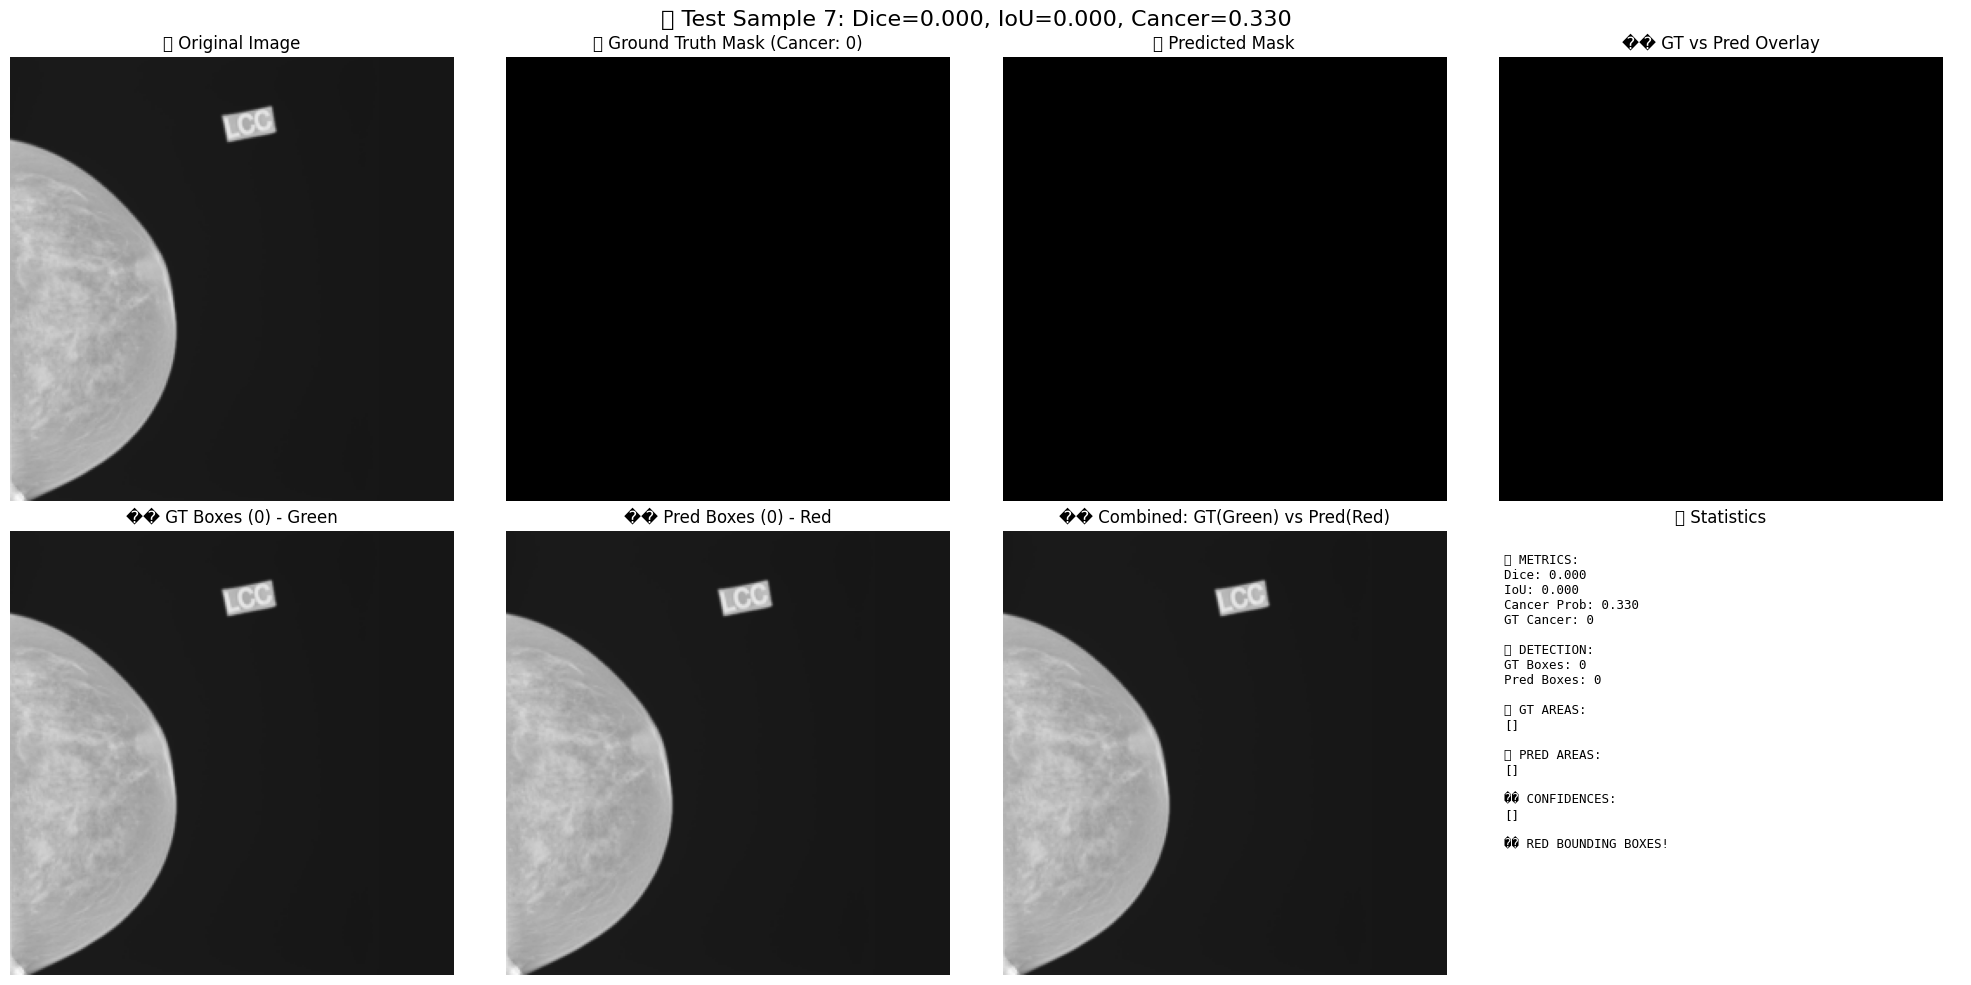

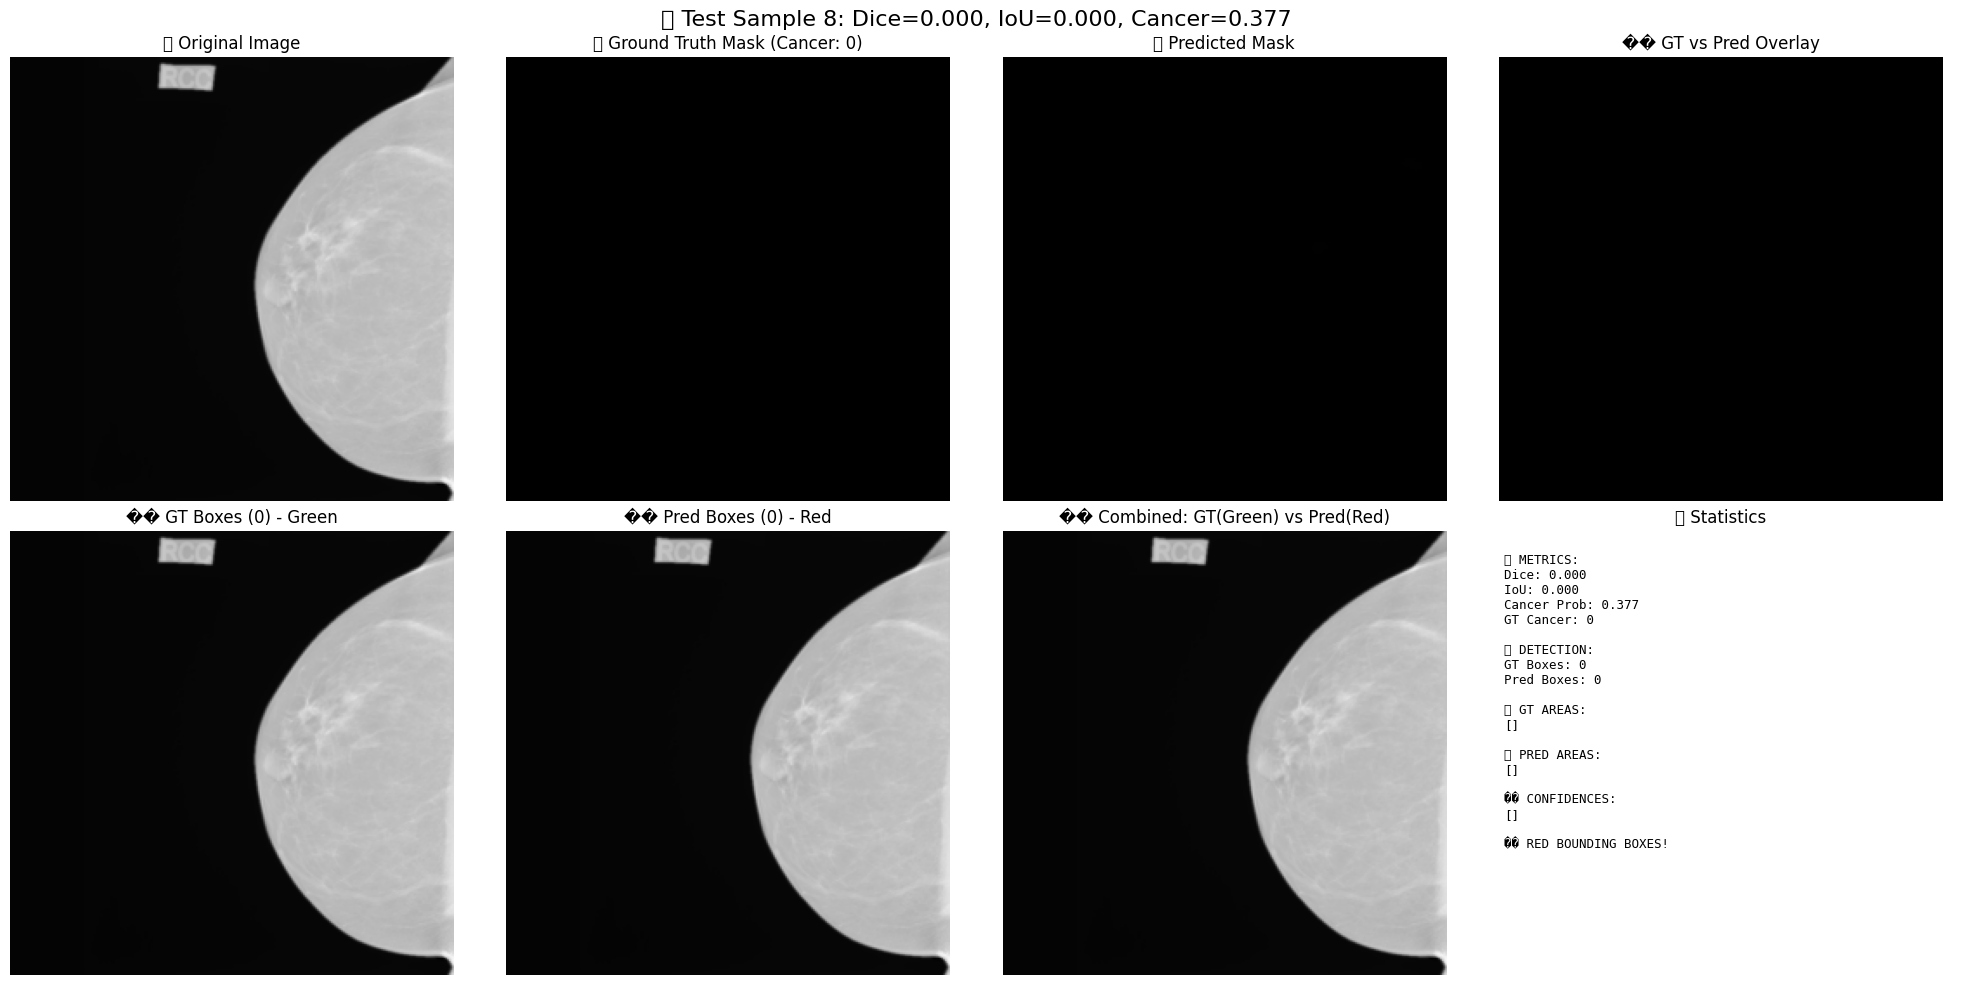

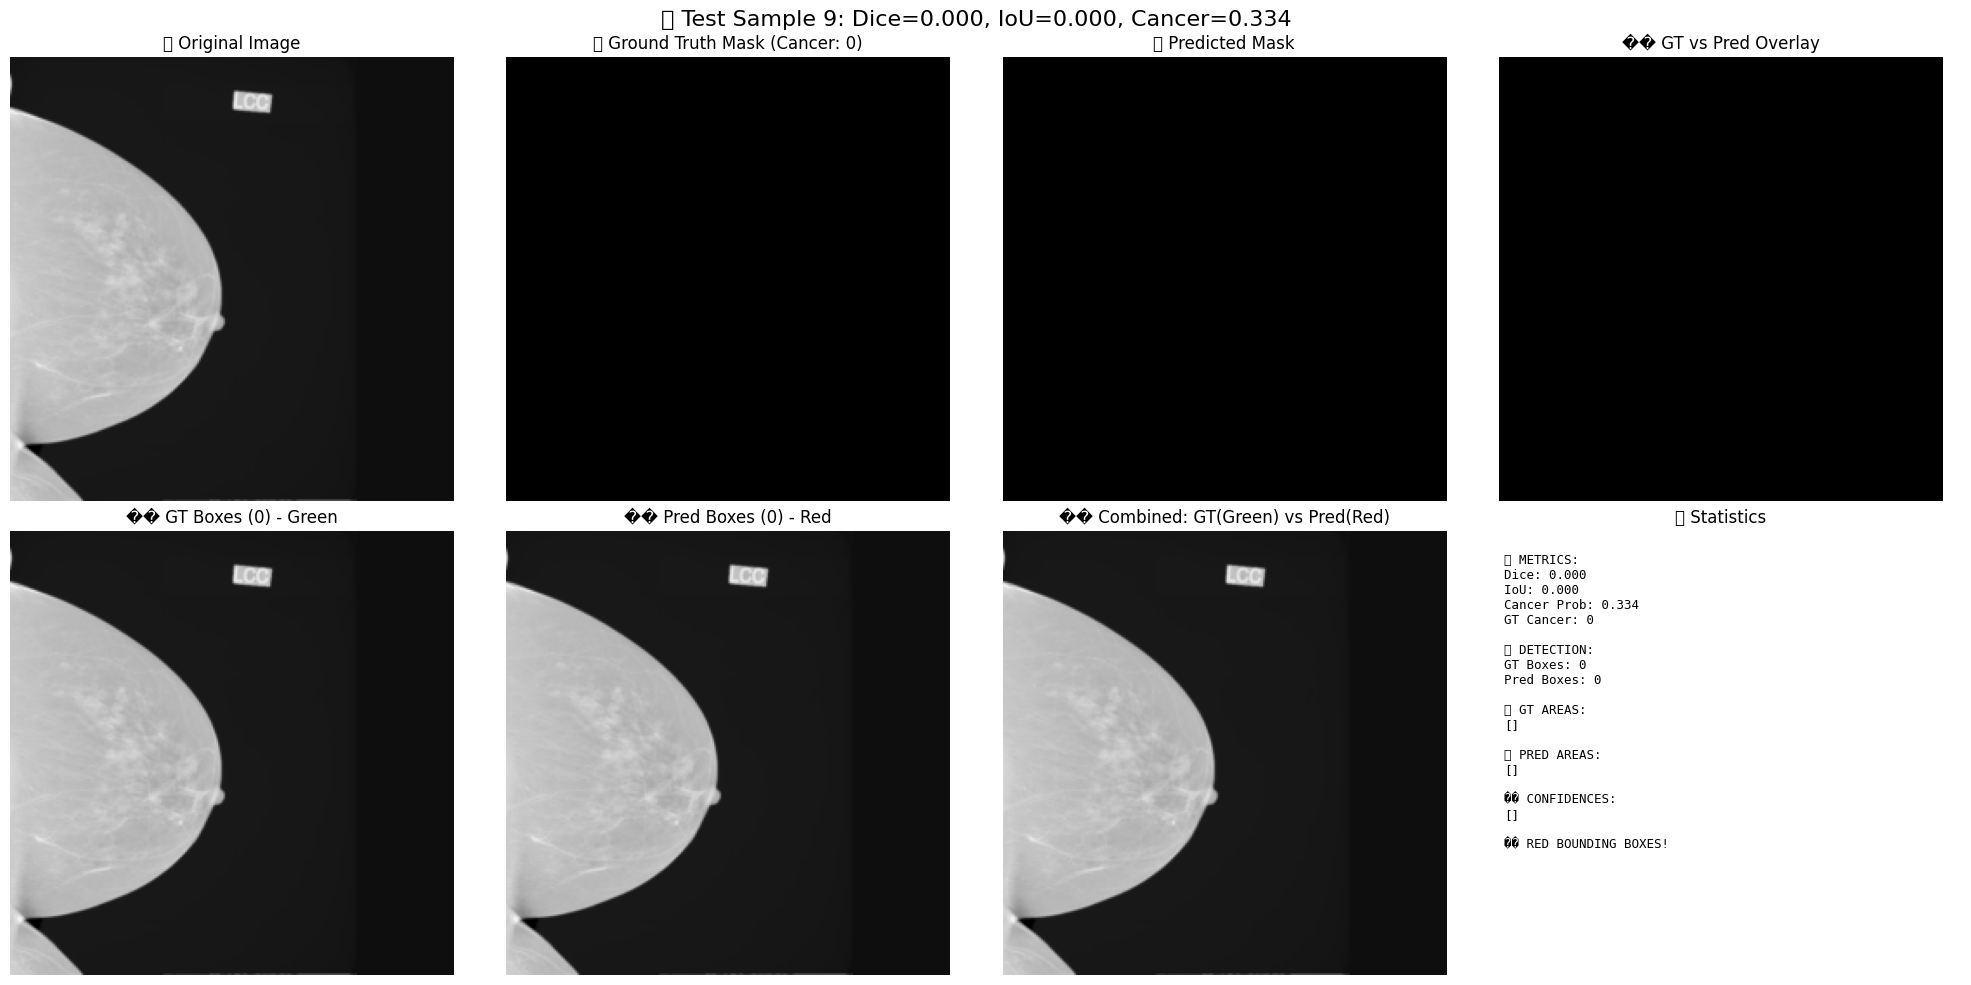

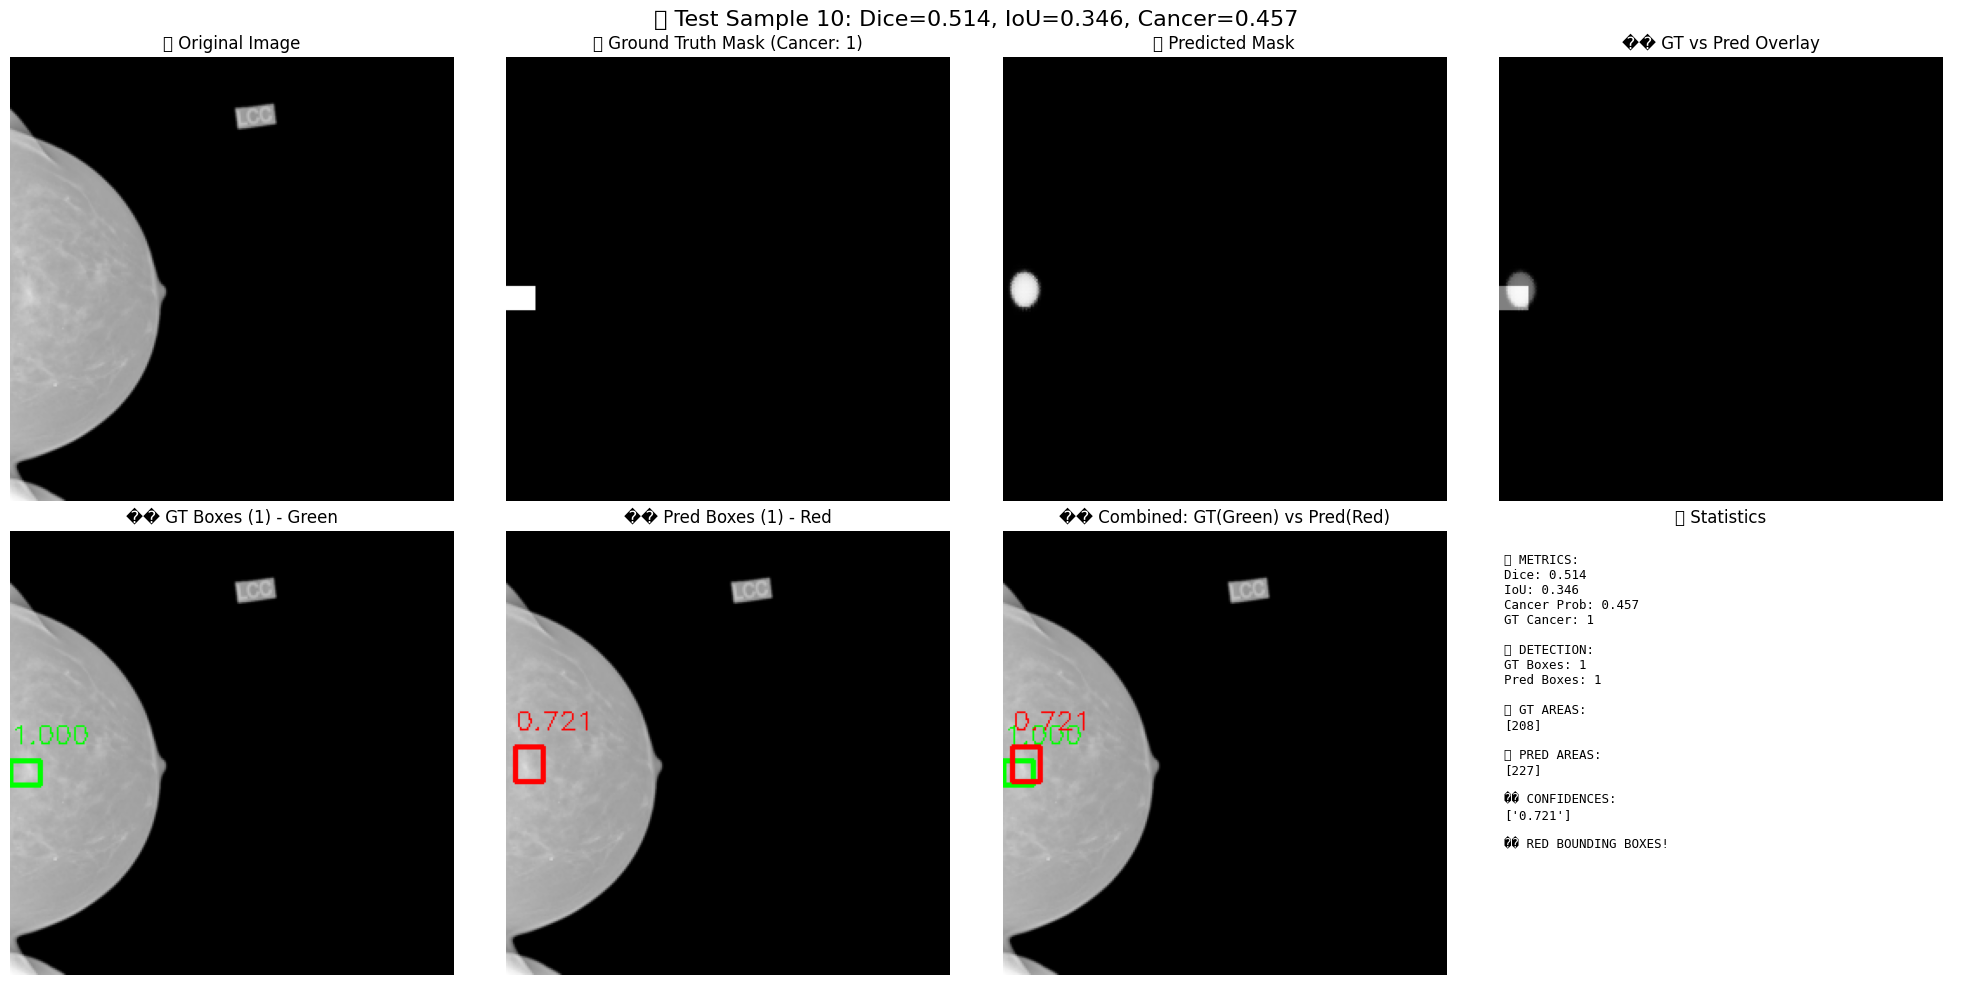

✅ Visualized 10 test samples with red bounding boxes!

📊 Evaluating model on test set...
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - classification_accuracy: 0.6809 - classification_loss: 0.7454 - loss: 1.3764 - segmentation_accuracy: 0.9910 - segmentation_dice_coefficient: 0.4167 - segmentation_iou_coefficient: 0.2711 - segmentation_loss: 0.6310

🎯 FINAL RESULTS:
📊 Test Loss: 1.3656
�� Segmentation Loss: 0.6625
📊 Classification Loss: 0.7030
📊 Segmentation Accuracy: 0.6744
�� Segmentation Dice: 0.9910
📊 Segmentation IoU: 0.3853
📊 Classification Accuracy: 0.2489

🎉 U-Net v6 Complete!
✅ Fixed normalization (img/max instead of /255)
✅ Dual outputs: Segmentation + Classification
✅ Red bounding boxes on original images
✅ Using your verified 11,606 file dataset!
✅ 50 epochs training

📁 File: Classifier_notebooks/unet_training_v5.ipynb
 This should work perfectly now!


In [9]:
# Test the model and create visualizations with red bounding boxes
print("�� Testing model with DUAL OUTPUTS + red bounding boxes...")
print("📊 Ground Truth vs Predictions with cv2.rectangle!")

# Visualize predictions with red bounding boxes
visualize_predictions_with_bboxes(model, test_dataset, num_samples=10)

# Evaluate model on test set
print("\n📊 Evaluating model on test set...")
test_results = model.evaluate(test_dataset, verbose=1)

print("\n🎯 FINAL RESULTS:")
print(f"📊 Test Loss: {test_results[0]:.4f}")
print(f"�� Segmentation Loss: {test_results[1]:.4f}")
print(f"📊 Classification Loss: {test_results[2]:.4f}")
print(f"📊 Segmentation Accuracy: {test_results[3]:.4f}")
print(f"�� Segmentation Dice: {test_results[4]:.4f}")
print(f"📊 Segmentation IoU: {test_results[5]:.4f}")
print(f"📊 Classification Accuracy: {test_results[6]:.4f}")

print("\n🎉 U-Net v6 Complete!")
print("✅ Fixed normalization (img/max instead of /255)")
print("✅ Dual outputs: Segmentation + Classification")
print("✅ Red bounding boxes on original images")
print("✅ Using your verified 11,606 file dataset!")
print("✅ 50 epochs training")

print("\n📁 File: Classifier_notebooks/unet_training_v5.ipynb")
print(" This should work perfectly now!")

In [10]:
import os
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Paths
BASE_DIR = '/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/test_balanced'
images_dir = f'{BASE_DIR}/images'
masks_dir = f'{BASE_DIR}/masks'
splits_dir = f'{BASE_DIR}/splits'

# Load splits
with open(f'{splits_dir}/train_files.json') as f:
    train_files = json.load(f)

print("🔍 CHECKING DATA SHAPES AND NORMALIZATION")
print("=" * 60)

# Check first 5 files from training set
for i, filename in enumerate(train_files[:5]):
    print(f"\n📁 File {i+1}: {filename}")
    
    # Load image
    img_path = f'{images_dir}/{filename}.npz'
    img_data = np.load(img_path)
    img = img_data['data']  # Original image
    
    print(f"   📷 Original Image:")
    print(f"      Shape: {img.shape}")
    print(f"      Data type: {img.dtype}")
    print(f"      Min value: {img.min()}")
    print(f"      Max value: {img.max()}")
    print(f"      Range: {img.max() - img.min()}")
    
    # Load mask
    mask_path = f'{masks_dir}/{filename}.png'
    mask = np.array(Image.open(mask_path))
    
    print(f"   🎭 Original Mask:")
    print(f"      Shape: {mask.shape}")
    print(f"      Data type: {mask.dtype}")
    print(f"      Unique values: {np.unique(mask)}")
    print(f"      Min value: {mask.min()}")
    print(f"      Max value: {mask.max()}")
    
    # Apply normalization (as in your notebook)
    img_normalized = img.astype(np.float32) / img.max()
    mask_normalized = mask.astype(np.float32) / 255.0
    
    print(f"   🔧 After Normalization:")
    print(f"      Image normalized range: {img_normalized.min():.4f} to {img_normalized.max():.4f}")
    print(f"      Mask normalized range: {mask_normalized.min():.4f} to {mask_normalized.max():.4f}")
    
    # Resize to IMG_SIZE (256, 256)
    import tensorflow as tf
    IMG_SIZE = (256, 256)
    
    img_resized = tf.image.resize(img_normalized[..., np.newaxis], IMG_SIZE)
    mask_resized = tf.image.resize(mask_normalized[..., np.newaxis], IMG_SIZE, method='nearest')
    
    print(f"   📐 After Resizing to {IMG_SIZE}:")
    print(f"      Image shape: {img_resized.shape}")
    print(f"      Mask shape: {mask_resized.shape}")
    print(f"      Image range: {img_resized.numpy().min():.4f} to {img_resized.numpy().max():.4f}")
    print(f"      Mask range: {mask_resized.numpy().min():.4f} to {mask_resized.numpy().max():.4f}")
    
    print("-" * 40)

# Summary statistics
print("\n📊 SUMMARY STATISTICS")
print("=" * 60)

# Check multiple files for statistics
img_ranges = []
mask_values = []

for filename in train_files[:20]:  # Check first 20 files
    # Image
    img_path = f'{images_dir}/{filename}.npz'
    img_data = np.load(img_path)
    img = img_data['data']
    img_ranges.append((img.min(), img.max()))
    
    # Mask
    mask_path = f'{masks_dir}/{filename}.png'
    mask = np.array(Image.open(mask_path))
    mask_values.extend(np.unique(mask))

print(f"📷 Image Statistics (first 20 files):")
print(f"   Min range across files: {min([r[0] for r in img_ranges])}")
print(f"   Max range across files: {max([r[1] for r in img_ranges])}")
print(f"   Average min: {np.mean([r[0] for r in img_ranges]):.1f}")
print(f"   Average max: {np.mean([r[1] for r in img_ranges]):.1f}")

print(f"\n🎭 Mask Statistics:")
print(f"   Unique values found: {sorted(set(mask_values))}")
print(f"   Most common values: {np.bincount(mask_values)}")

# Test normalization on a sample
print(f"\n🧪 NORMALIZATION TEST")
print("=" * 60)

sample_filename = train_files[0]
img_path = f'{images_dir}/{sample_filename}.npz'
img_data = np.load(img_path)
img = img_data['data']

print(f"Sample image: {sample_filename}")
print(f"Original range: {img.min()} to {img.max()}")

# Test different normalization methods
normalization_methods = {
    "img / img.max()": img / img.max(),
    "img / 255.0": img / 255.0,
    "(img - img.min()) / (img.max() - img.min())": (img - img.min()) / (img.max() - img.min())
}

for method_name, normalized_img in normalization_methods.items():
    print(f"{method_name}:")
    print(f"   Range: {normalized_img.min():.4f} to {normalized_img.max():.4f}")
    print(f"   Mean: {normalized_img.mean():.4f}")
    print(f"   Std: {normalized_img.std():.4f}")

print("\n✅ Data shape and normalization check complete!")

🔍 CHECKING DATA SHAPES AND NORMALIZATION

📁 File 1: 116641456282645984331377310208528213862
   📷 Original Image:
      Shape: (512, 512)
      Data type: uint16
      Min value: 662
      Max value: 3742
      Range: 3080
   🎭 Original Mask:
      Shape: (512, 512)
      Data type: uint8
      Unique values: [  0 255]
      Min value: 0
      Max value: 255
   🔧 After Normalization:
      Image normalized range: 0.1769 to 1.0000
      Mask normalized range: 0.0000 to 1.0000
   📐 After Resizing to (256, 256):
      Image shape: (256, 256, 1)
      Mask shape: (256, 256, 1)
      Image range: 0.1769 to 0.9474
      Mask range: 0.0000 to 1.0000
----------------------------------------

📁 File 2: 28719955039438647404216562026885325799
   📷 Original Image:
      Shape: (512, 512)
      Data type: uint16
      Min value: 215
      Max value: 3055
      Range: 2840
   🎭 Original Mask:
      Shape: (512, 512)
      Data type: uint8
      Unique values: [  0 255]
      Min value: 0
      Max va